## DeepEcho: Industrial Audio Anomaly Detection - EDA
---

### Objective
> This notebook explores the **MIMII Pump Dataset** to:
> 1. Understand the dataset structure and quality
> 2. Compare normal vs abnormal pump sounds
> 3. Extract audio features for analysis

### Imports & Path Setup

In [242]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
import IPython.display as ipd

In [246]:
plt.style.use('dark_background')
DATA_PATH = "../data/raw/pump"
PUMP_IDS = ["id_00"]

### Loading the files

Loading the files using lru_cache to avoid searching the folders each time

In [247]:
from functools import lru_cache
from pathlib import Path

@lru_cache(maxsize=1)
def get_normal_files(pump_id):
	return sorted(Path(DATA_PATH).glob(f"{pump_id}/normal/*.wav"))

@lru_cache(maxsize=1)
def get_abnormal_files(pump_id):
	return sorted(Path(DATA_PATH).glob(f"{pump_id}/abnormal/*.wav"))

### Dataset Count Check

In this section, we count how many normal and abnormal audio files exist for each pump.
This helps us understand the dataset before training.

In [248]:
summary = []

for pid in PUMP_IDS:
	n_normal = len(get_normal_files(pid))
	n_abnormal = len(get_abnormal_files(pid))
	ratio = round(n_normal / max(n_abnormal, 1), 2)
	summary.append((pid, n_normal, n_abnormal, ratio))

print("Pump  | Normal | Abnormal | Ratio (Normal/Abnormal)")
for pid, n_normal, n_abnormal, ratio in summary:
	print(f"{pid} | {n_normal:>6} | {n_abnormal:>8} | {ratio}")

Pump  | Normal | Abnormal | Ratio (Normal/Abnormal)
id_00 |   1006 |      143 | 7.03


#### Quick conclusion from counts
- Dataset is imbalanced for this pump (id_00).
- Normal samples are much more than abnormal samples (about 7x to 10x).
- This means we should be careful during training and use imbalance handling later.

### Data Integrity Check

In this section, we verify that the audio files have the same format across all pumps and classes.
We check sample rate and duration to make sure training will be stable.

In [249]:
def check_data_integrity(directory):
	sr_set = set()
	duration_set = set()
	for wav_path in Path(directory).rglob('*.wav'):
		with sf.SoundFile(wav_path) as f:
			sr = f.samplerate
			frames = f.frames
			duration = frames / sr
		sr_set.add(sr)
		duration_set.add(round(duration, 3))
	print(f"Checked: {directory}")
	print(f"Sample Rates Found: {sr_set}")
	print(f"Durations Found: {duration_set}")
	print("-" * 40)

for machine_id in PUMP_IDS:
	machine_path = os.path.join(DATA_PATH, machine_id)
	if not os.path.isdir(machine_path):
		continue
	check_data_integrity(os.path.join(machine_path, 'normal'))
	check_data_integrity(os.path.join(machine_path, 'abnormal'))

Checked: ../data/raw/pump/id_00/normal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------
Checked: ../data/raw/pump/id_00/abnormal
Sample Rates Found: {16000}
Durations Found: {10.0}
----------------------------------------


#### Quick conclusion from quality check
- All checked files have sample rate: 16,000 Hz
- All checked files have duration: 10.0 seconds
- The dataset format is consistent, so we can continue to visualization and feature analysis

### Audio Sanity Check

In [250]:
ipd.Audio(filename=get_abnormal_files("id_00")[0])  # Abnormal sample from pump ID_00

In [251]:
ipd.Audio(filename=get_normal_files("id_00")[0])  # Normal sample from pump ID_00

### Visual Comparison (Normal vs Abnormal)

We compare multiple normal/abnormal samples from each pump.
We use waveform and mel spectrogram with the same plot scales to make fair comparisons.

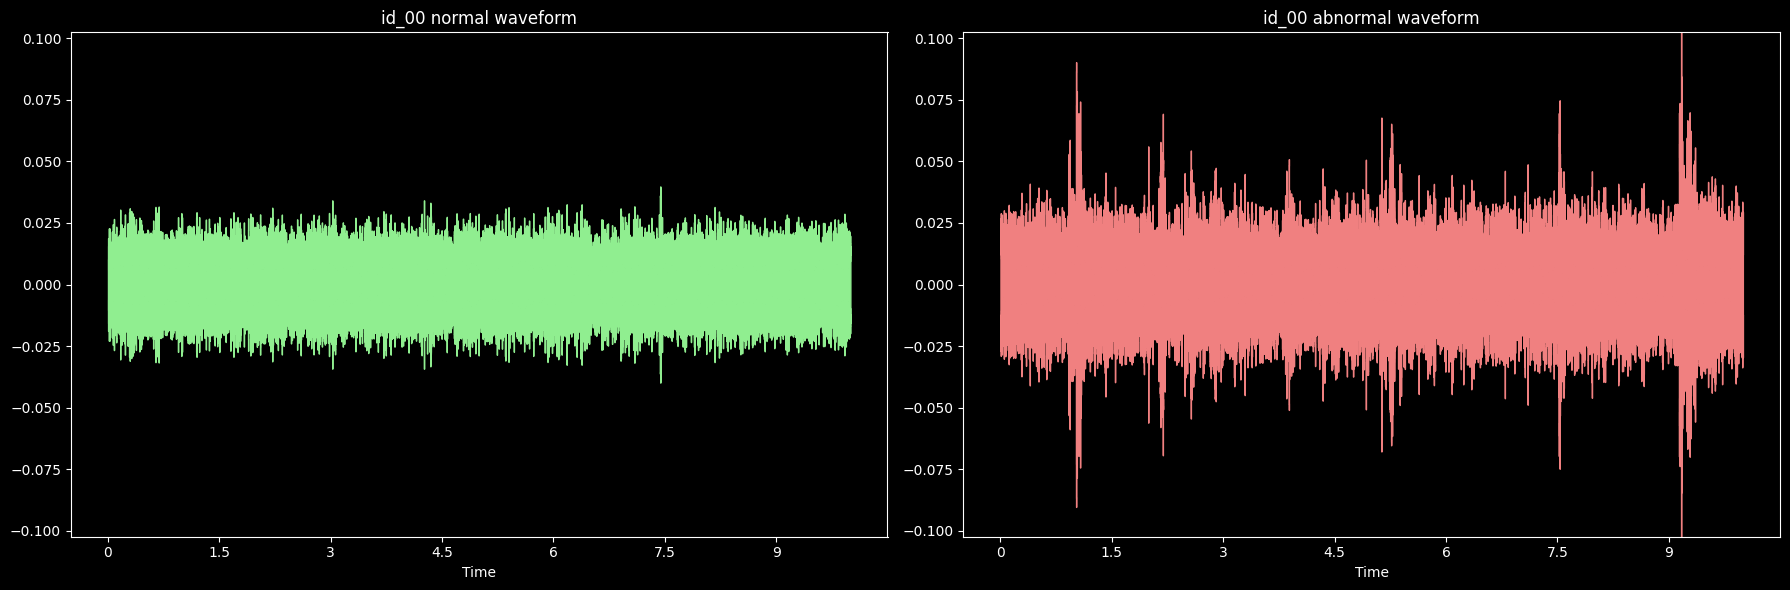

In [252]:
def plot_waveforms_all_pumps(pump_ids):
	pairs = []
	global_y_lim = 0.0
	n_files = get_normal_files(pump_ids[0])
	a_files = get_abnormal_files(pump_ids[0])
	for pid in pump_ids:
		n_file = n_files[0]
		a_file = a_files[0]
		y_n, sr_n = librosa.load(n_file, sr=None)
		y_a, sr_a = librosa.load(a_file, sr=None)
		pairs.append((pid, y_n, sr_n, y_a, sr_a))
		global_y_lim = max(global_y_lim, np.max(np.abs(y_n)), np.max(np.abs(y_a)))

	fig, axes = plt.subplots(len(pump_ids), 2, figsize=(18, 6), sharex=False)
	if len(pump_ids) == 1:
		axes = np.array([axes])

	for i, (pid, y_n, sr_n, y_a, sr_a) in enumerate(pairs):
		librosa.display.waveshow(y_n, sr=sr_n, ax=axes[i, 0], color="lightgreen")
		axes[i, 0].set_title(f"{pid} normal waveform")
		axes[i, 0].set_ylim([-global_y_lim, global_y_lim])
		librosa.display.waveshow(y_a, sr=sr_a, ax=axes[i, 1], color="lightcoral")
		axes[i, 1].set_title(f"{pid} abnormal waveform")
		axes[i, 1].set_ylim([-global_y_lim, global_y_lim])

	plt.tight_layout()
	plt.show()

plot_waveforms_all_pumps(PUMP_IDS)


#### Quick conclusion from visual comparison
- Normal pumps: smooth, quiet signal.
- Abnormal pumps: lots of noise and spikes.
- Most of the time the difference is clear.

Creating a dictionary to store the file path and it's label (normal / abnormal)

In [253]:
from random import shuffle

my_files = {}
for pump_id in PUMP_IDS:
	for file in get_normal_files(pump_id):
		my_files[f"{DATA_PATH}/{pump_id}/normal/{file.name}"] = 0
	for file in get_abnormal_files(pump_id):
		my_files[f"{DATA_PATH}/{pump_id}/abnormal/{file.name}"] = 1

files_list = list(my_files.items())
shuffle(files_list)
my_files = dict(files_list)
print(f"Total files: {len(my_files)}")

Total files: 1149


### Feature Extraction

Extracting 13 audio features for each file to build a dataset for analysis.

#### Why these features

I spent some time testing and picking the audio features that matter most here.
I wanted features that make normal and abnormal sounds easier to separate.
I explained the meaning of each feature in the code comments.

In [254]:
def extract_features(file_path, label):
	y, sr = librosa.load(file_path, sr=None)

	# Extract how far on average the values spread away from the mean.
	# small values = close to mean
	signal_variance = float(np.var(y))

	# How much the sound repeats itself in each 0.5 second
	# high value = shifted sound matches original
	auto_corr = librosa.autocorrelate(y, max_size=int(0.5 * sr))
	min_look_index = int(0.02 * sr) # Skip the first 20ms to avoid signal self-similarity
	clean_rhythm_signal = np.abs(auto_corr[min_look_index:])
	rhythm_echo_strength = float(np.mean(clean_rhythm_signal))

	# How much the center of brightness of the sound move over time
	# high variance = centroid jumps up and down a lot
	stft = np.abs(librosa.stft(y))
	centroids = librosa.feature.spectral_centroid(S=stft, sr=sr)
	centroid_variance = float(np.var(centroids))

	# How much the energy change from low to high frequencies
	# negative slope = more low frequencies, positive slope = more high frequencies
	means_per_bin = np.mean(stft, axis=1)
	frequencies = librosa.fft_frequencies(sr=sr)
	slope, _ = np.polyfit(frequencies, means_per_bin, 1)
	spectral_slope = float(slope)

	# Capture fine high frequency spectral texture
	# large mfcc_12_max with low mfcc_12_std = isolated spike
	# large mfcc_12_std = repeating texture change
	mfcc_12 = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)[12]
	mfcc_12_max = float(np.max(mfcc_12))
	mfcc_12_std = float(np.std(mfcc_12))

	# Count sign changes
	# high count = lot of rapid sign changes, and strong high frequency 
	zcr_array = librosa.feature.zero_crossing_rate(y=y)
	zcr_mean = float(np.mean(zcr_array))

	# The sharpness of frequency peaks
	# low value = energy is spread across many frequencies
	spectral_crest = np.max(stft, axis=0) / (np.mean(stft, axis=0) + 1e-6)
	spectral_crest_max = float(np.max(spectral_crest))
	

	# How much the sound shifts between clear tone and noise
	# high values = more shift between clear tone and noise, low values = more consistent texture
	flatness_array = librosa.feature.spectral_flatness(y=y)
	spectral_flatness_range = float(np.max(flatness_array) - np.min(flatness_array))

	# Whether the sound has strong frequency structure or just looks flat/noisy
	# low value = flat
	contrast_matrix = librosa.feature.spectral_contrast(S=stft, sr=sr)
	spectral_contrast_mean = float(np.mean(contrast_matrix))

	# The average energy or loudness of the sound
	# high rms = the sound is generally loud and energetic
	rms_array = librosa.feature.rms(y=y)
	rms_mean = float(np.mean(rms_array))
	rms_std = float(np.std(rms_array))

	# How strong the reapeating rhythm is in the sound
	# high tempogram_mean = the sound has a clear repeated pattern
	tempogram = librosa.feature.tempogram(y=y, sr=sr)
	tempogram_mean = float(np.mean(tempogram))

	row = {
		"file_path": file_path,
		"signal_variance": round(signal_variance, 8),
		"rhythm_echo_strength": round(rhythm_echo_strength, 8),
		"centroid_variance": round(centroid_variance, 8),
		"spectral_slope": round(spectral_slope, 8),
		"mfcc_12_max": round(mfcc_12_max, 8),
		"mfcc_12_std": round(mfcc_12_std, 8),
		"zcr_mean": round(zcr_mean, 8),
		"spectral_crest_max": round(spectral_crest_max, 8),
		"spectral_flatness_range": round(spectral_flatness_range, 8),
		"spectral_contrast_mean": round(spectral_contrast_mean, 8),
		"rms_mean": round(rms_mean, 8),
		"rms_std": round(rms_std, 8),
		"tempogram_mean": round(tempogram_mean, 8),
		"label": label
	}
	return row

### Build Dataset

file_path | features | label

In [255]:

dataset_rows = []
for file_path, label in my_files.items():
	if os.path.exists(file_path):
		features = extract_features(file_path, label)
		dataset_rows.append(features)

df = pd.DataFrame(dataset_rows)
print(df.head())
df.to_csv("pump_features.csv", index=False)


                                    file_path  signal_variance  \
0  ../data/raw/pump/id_00/normal/00000482.wav         0.000092   
1  ../data/raw/pump/id_00/normal/00000061.wav         0.000104   
2  ../data/raw/pump/id_00/normal/00000832.wav         0.000092   
3  ../data/raw/pump/id_00/normal/00000888.wav         0.000096   
4  ../data/raw/pump/id_00/normal/00000640.wav         0.000087   

   rhythm_echo_strength  centroid_variance  spectral_slope  mfcc_12_max  \
0              1.225882       14315.253547       -0.000049     8.229321   
1              0.794912       29193.620993       -0.000052    13.652294   
2              0.639829       11035.866457       -0.000052     7.012926   
3              0.814659       20741.092975       -0.000051     8.593815   
4              0.405527       11042.066892       -0.000059     9.456568   

   mfcc_12_std  zcr_mean  spectral_crest_max  spectral_flatness_range  \
0     3.362396  0.093121           36.729195                 0.077828   
1     

### Exploratory Plots



#### Scatter plot


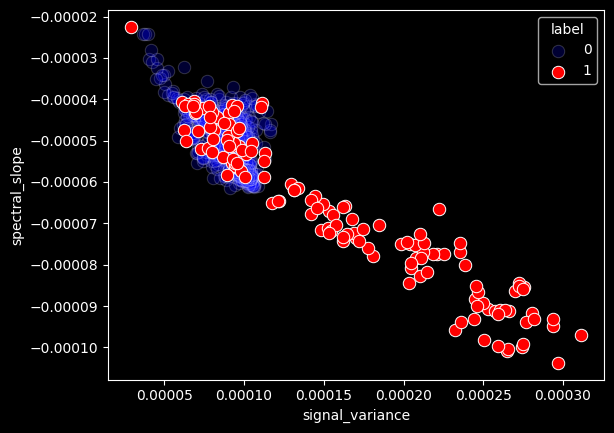

In [260]:
fig, ax = plt.subplots()

sns.scatterplot(
	data=df[df["label"] == 0],
	x="signal_variance",
	y="spectral_slope",
	color="blue",
	alpha=0.2,
	s=80,
	ax=ax,
	label="0",
)

sns.scatterplot(
	data=df[df["label"] == 1],
	x="signal_variance",
	y="spectral_slope",
	color="red",
	alpha=1.0,
	s=80,
	ax=ax,
	label="1",
)

ax.legend(title="label")
plt.show()


#### Quick conclusion from scatter plot
- Normal audios (blue) are mostly in the top left.
- This means normal sounds have a slope closer to flat.
- Abnormal audios (red) are lower, with more negative slope values.
- More negative slope means abnormal sounds have more low frequency energy.
- Blue audios are also closer together, which means normal audio is more consistent and closer to its average behavior.
- Red audios are more spread, which means abnormal is more variable and farther from the average behavior.

#### Pairplot

to visualize the relationship between all features and how they separate normal and abnormal samples.

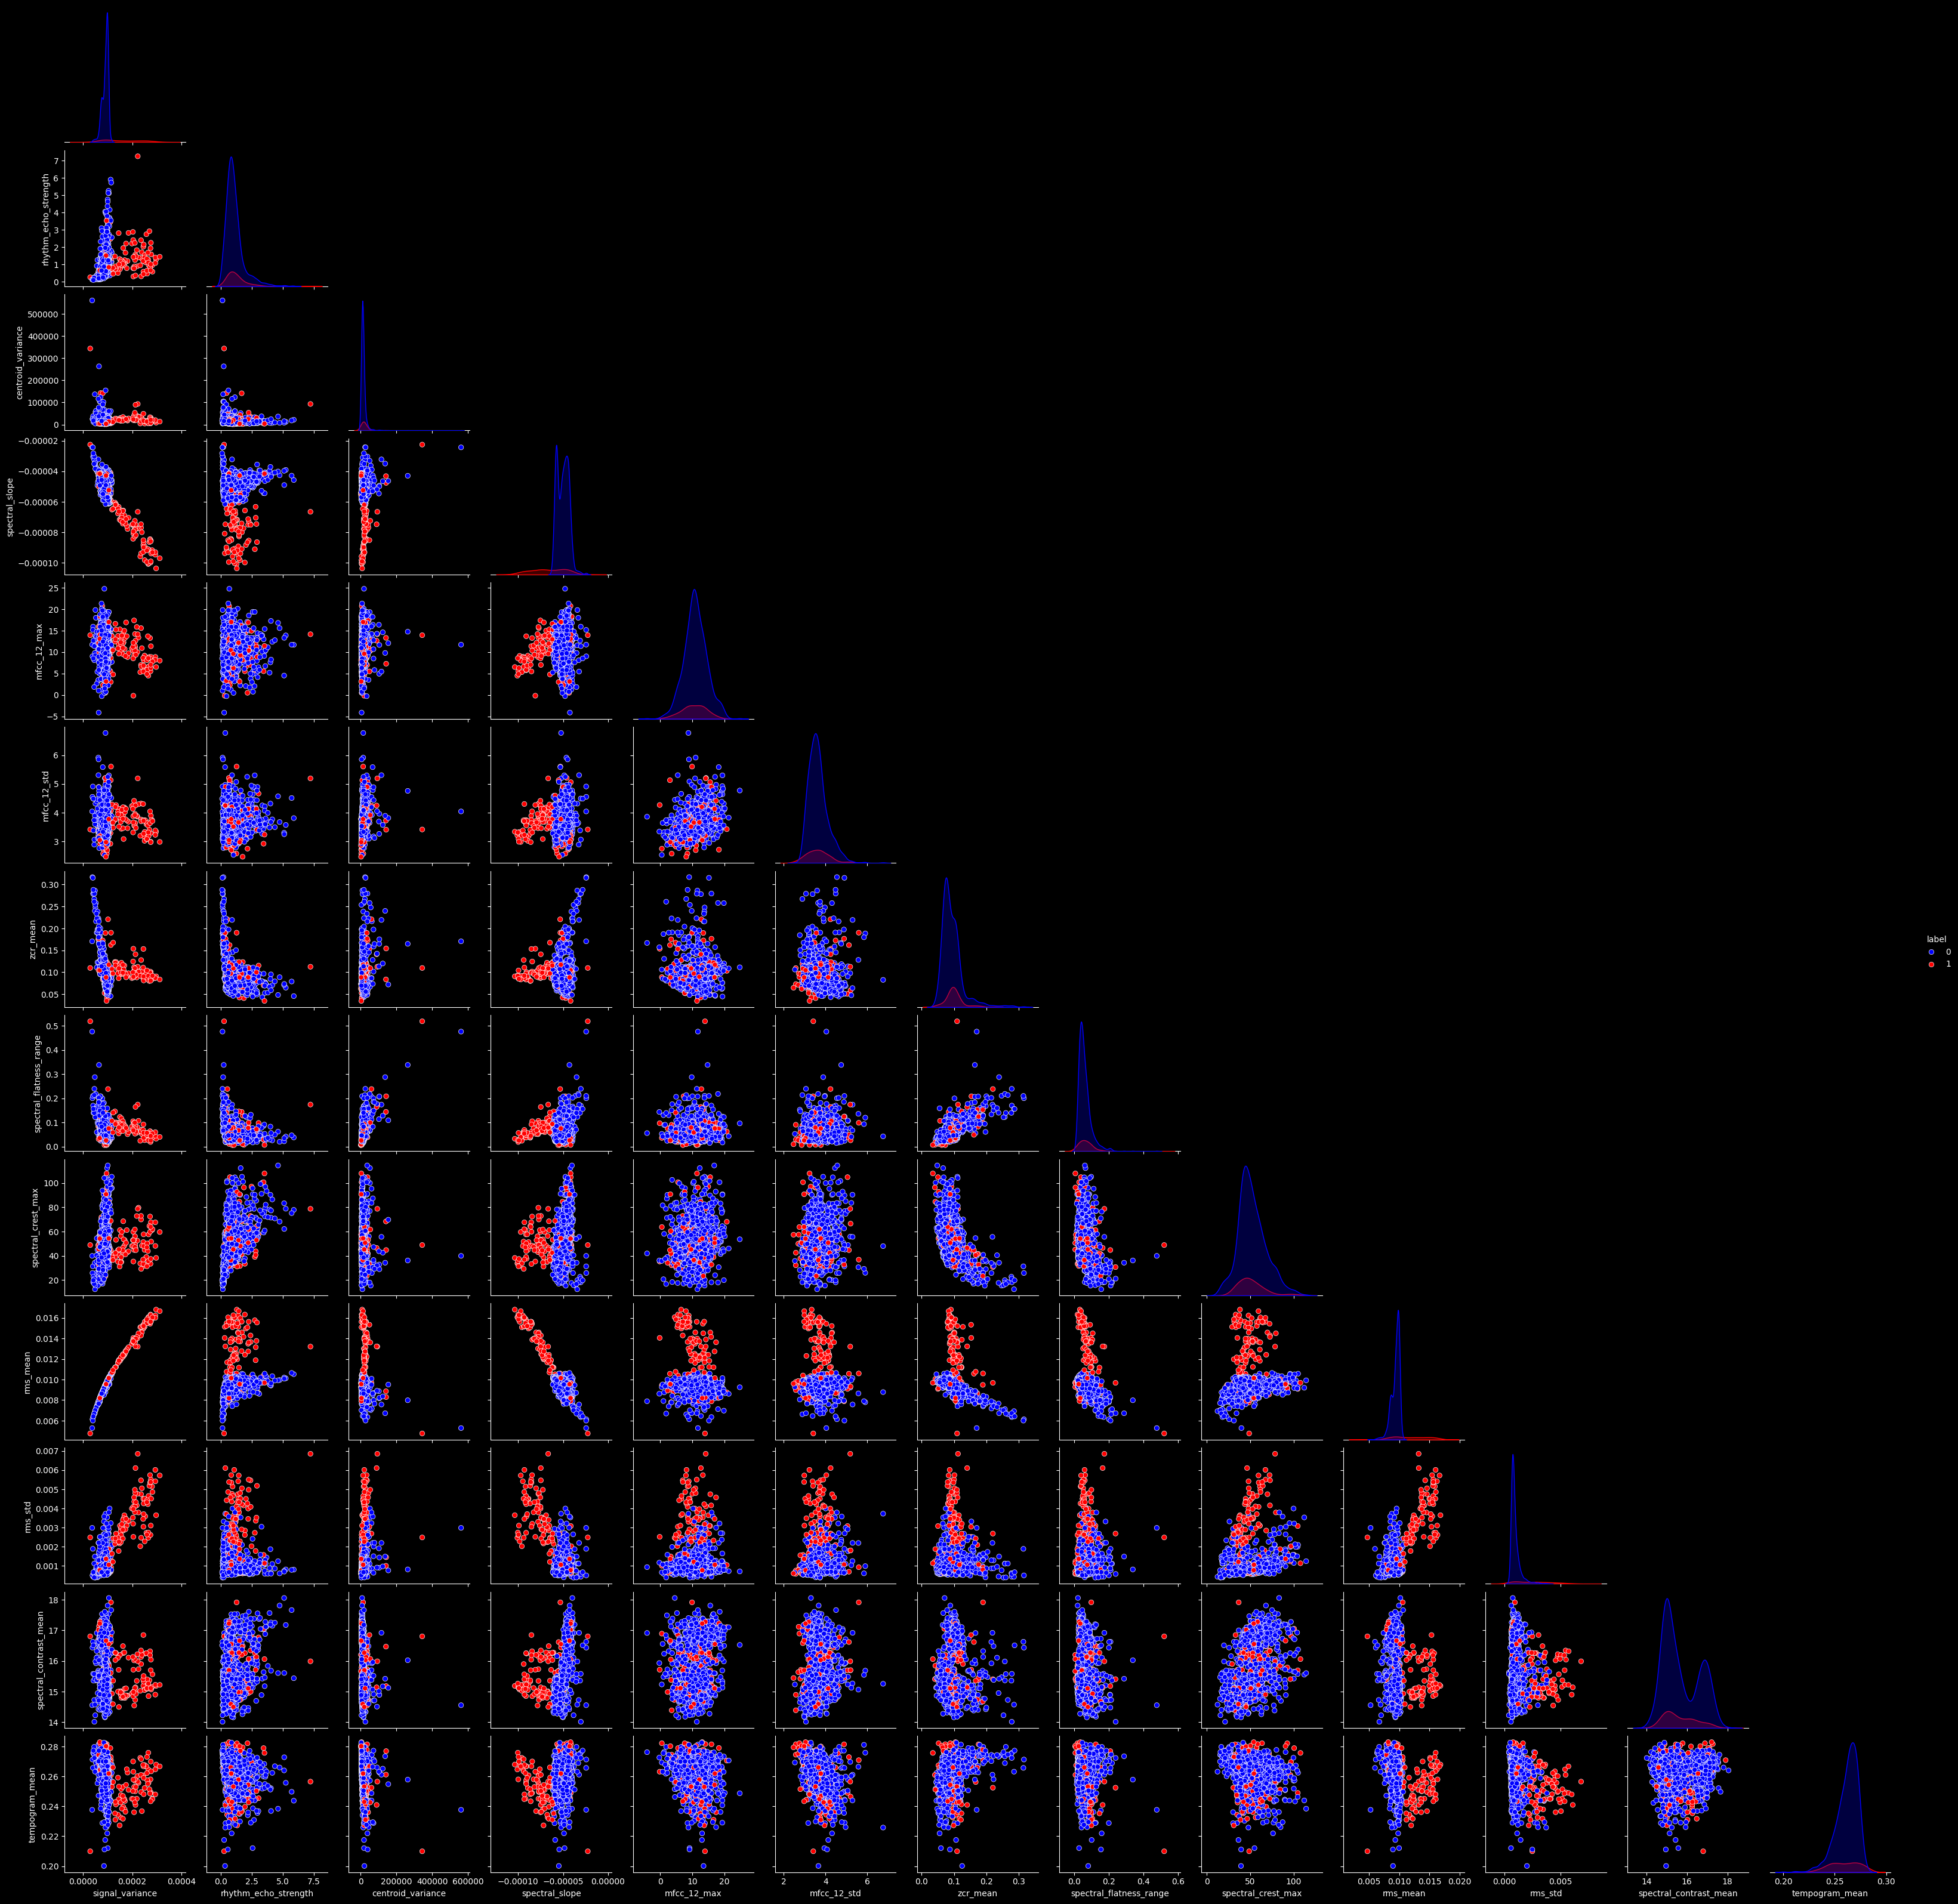

In [257]:
df = pd.read_csv("pump_features.csv")

features_list = [
	'signal_variance', 'rhythm_echo_strength', 'centroid_variance', 
	'spectral_slope', 'mfcc_12_max', 'mfcc_12_std', 'zcr_mean', 'spectral_flatness_range', 'spectral_crest_max', 'rms_mean', 'rms_std', 'spectral_contrast_mean', 'tempogram_mean', 'label'
]
df_subset = df[features_list]
sns.pairplot(df_subset, hue='label', palette={0: 'blue', 1: 'red'}, corner=True)
plt.show()


#### What we see in the pairplot

- Some feature pairs show almost clear separation.
- Other pairs look more mixed, with blue and red overlapping a lot.
- Even when features don't separate well alone, they can still help when used together in a ML model.


### Final Conclusion

Dataset is consistent but imbalanced. Visual differences are usually clear. We have 13 features that together should help classify normal vs abnormal sounds. Ready for model training.